# CMDB asset matching

**Recipe 22** · Level 2 (Easy) · Decision type: `Choice`

Link differently worded software asset descriptions to a canonical configuration-management record from a bounded candidate list or a no-match outcome.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S06: [TypeSafe AI: Cookbooks](https://docs.typesafe.ai/cookbooks)

## What you will build

A CMDB reconciliation assistant for a software asset-discovery feed. Python holds a pool of sixteen canonical CMDB records and, for each observed asset, retrieves the subset whose vendor and product wording overlaps the asset's own -- plain normalized word overlap, no model call, and no fixed count: the candidate count varies per asset, and an asset sharing no wording with anything in the pool retrieves none at all. Jev then reads one `Choice` question over the retrieved candidates (plus the explicit fallback `no_match`) and decides which one, if any, describes the same asset, reading the vendor, product, major version and edition exactly as a discovery scan reported them -- never standardized, and often worded quite differently from the canonical record's own spelling. Python owns everything else: the retrieval, the candidate descriptions, the rule that links a confident real match to its record (the one outcome with a simulated side effect), reports `no_match` as a final result whatever its confidence (or without ever asking Jev at all, when retrieval finds nothing to offer), and sends anything else uncertain to an explicit `review` outcome. This notebook replays 38 stored, hand-written synthetic answers (36 across the 40 scored assets, plus 2 of the 3 `demo` assets); 5 of the 43 fixtures overall -- 4 scored, 1 demo -- retrieve no candidate at all and need no stored answer. Several are wrong on purpose and in different ways, so the lesson about what a confidence gate can and cannot catch is an honest one. By the end you will have looked at individual typed answers across the full range of this recipe's hard cases -- two major-version siblings, two edition-only siblings, a lexical look-alike that is a genuinely different product, and an asset with no canonical record at all -- seen the rule that acts on them and its one simulated side effect (a link written to the CMDB, never executed), checked that rule's own accuracy against two trivial, Jev-free baselines it must clearly beat, seen exactly what letting `no_match` bypass the confidence gate costs and buys, and run an evaluation that chooses its one setting on `validation` and reports link accuracy, the false-link rate, coverage, risk and `no_match`'s own precision and recall on `test`.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 38 stored answers in `fixtures/responses.json` offline (the other 5 of the 43 fixtures retrieve no candidate at all and so are never asked, see "The questions" below); setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
import json

from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    evaluate_outcomes,
    per_class_metrics,
    select_confidence_threshold,
    selective_curve,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ActionLog, ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_risk_coverage,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." Pattern decision: a validation line in a synthetic/scripted run carries both labels,
# since it is simultaneously a selection step and a pipeline check.
selection = " (a selection step, not a reported result)"

# The simulated side effects this recipe can produce: a link written from an asset to a
# canonical record (the only outcome with a side effect), a backlog of unmatched assets (no
# write -- see "Python's part" below), and a queue of assets held for a person to look at.
# Nothing here sends, moves or changes anything real (jev_cookbook.simulation;
# CONTRIBUTING.md section 4).
actions = ActionLog()
backlog = ReviewQueue()
queue = ReviewQueue()

# Every one of the 43 examples in fixtures/ needs at most one request, and five need none at
# all (see "The questions"). This cache makes sure an asset that is shown individually and
# later scored in its split is decided once, so the whole notebook makes at most 38 requests in
# live mode, never more.
decided = {}


def decide(example):
    if example.id not in decided:
        candidates = helpers.shortlist(example.fields["vendor"], example.fields["product"])
        if not candidates:
            decided[example.id] = (candidates, None)
        else:
            questions = helpers.build_questions(candidates)
            answer = backend.decide(helpers.build_state(example.fields), questions)["match"]
            decided[example.id] = (candidates, answer)
    return decided[example.id]


run_header(
    22,
    "CMDB asset matching",
    backend=backend,
    n_examples=len(scored),
)

Recipe 22: CMDB asset matching
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 40 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: an `asset_id`, and the observed `vendor`, `product`, `version` and `edition`, exactly as a discovery scan reported them. `build_state` passes on the vendor, product, version and edition only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its asset.

In [2]:
demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-lookalike"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "asset_id": "AST-3001",
  "vendor": "Candlewood",
  "product": "InkPress Reader",
  "version": "9.12.447",
  "edition": "Standard"
}
Jev sees:
{
  "vendor": "Candlewood",
  "product": "InkPress Reader",
  "version": "9.12.447",
  "edition": "Standard"
}


## The questions

There is one question, and it asks one thing: does this observed asset describe the same canonical software as any of the candidate CMDB records, or none of them? A `Choice` fits because the outcomes are exclusive and Jev should commit to exactly one ([S02](https://docs.typesafe.ai/primitives) describes `Choice` as picking exactly one option from a fixed, known set with no inherent order). Python retrieves the candidates before Jev ever sees the asset: `shortlist` in `helpers.py` ranks the sixteen canonical records by **normalized vendor/product token overlap** -- lowercasing, folding common vendor aliases and corporate suffixes (`"Candlewood Systems Incorporated"`, `"Redfern, Inc."`, `"Ashgrove SE"` all normalize the same as their plain names), then comparing word sets -- and keeps every record above zero overlap, up to five (`MAX_CANDIDATES`). Unlike a fixed-size shortlist, the **count varies per asset**: the cell below shows the raw overlap scores for one asset, and the distribution over every fixture in this recipe, derived below rather than asserted in prose. An asset with **zero** candidates is never asked about at all: the only possible `Choice` would offer one option (the fallback alone), and a single-option Choice is never sent (a forced answer belongs to Python, not a request). Retrieval ranks on vendor and product wording alone; it never looks at version or edition, on purpose, so two records that differ only by version or only by edition -- or a genuinely different product that happens to share a vendor's name -- can all be retrieved side by side. Telling those apart is exactly the judgment this question asks Jev to make, which is why the shared instructions state the matching rule in words: a record is the same asset only when vendor, product, major version and edition all agree. Each candidate's own description carries all four, so the information needed to apply that rule is there for every option. The last option, `no_match`, is the explicit fallback the use case names for an asset that matches none of the candidates.

A `Choice` answer's [confidence](../../docs/glossary.md#confidence) is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` ([S03](https://docs.typesafe.ai/confidence)): 0 when the top option holds no more than its even share, 1 when one option holds everything. Because `n` -- the option count -- varies with the candidate count, this formula is what makes confidence comparable across assets that were offered different numbers of candidates. The option list (and so `n`) is part of what `replay_key` hashes, along with the state; because the shortlist is built fresh per asset, each asset's request has its own key, and changing `shortlist` invalidates every stored answer at once (`tests/test_helpers.py` catches exactly this: `test_every_replay_key_in_the_fixtures_matches_the_current_question`).

[S06](https://docs.typesafe.ai/cookbooks) frames this kind of decision as retrieval plus a narrow judgment embedded in code that keeps control flow: Python finds the candidates, Jev picks one of them (or none), and Python (`match_record` in `helpers.py`, below) decides what that pick is allowed to do -- write a link, report `no_match` as a final result, or hold the answer back for review.

In [3]:
scores = helpers.similarity_scores(example.fields["vendor"], example.fields["product"])
print("retrieval similarity against every canonical record (nonzero only):")
for record_id, score in sorted(scores.items(), key=lambda kv: (-kv[1], kv[0])):
    if score > 0:
        print(f"  {record_id}  {score:.4f}  {helpers.CMDB_RECORDS[record_id]}")

candidates, _ = decide(example)
print()
print("candidate count for this asset:", len(candidates))
print("candidates, with their ids and fields:")
for record_id in candidates:
    print(f"  {record_id}: {helpers.CMDB_RECORDS[record_id]}")
questions = helpers.build_questions(candidates)
match = questions["match"]
print()
print(match.instructions)
print()
for name, description in match.criteria.items():
    print(f"{name}")
    print(f"  {description}")

retrieval similarity against every canonical record (nonzero only):
  CMDB-04  0.6667  {'vendor': 'Candlewood', 'product': 'InkPress', 'major_version': '12', 'edition': 'Pro'}
  CMDB-05  0.2500  {'vendor': 'Candlewood', 'product': 'PixelForge', 'major_version': '27', 'edition': 'Standard'}

candidate count for this asset: 2
candidates, with their ids and fields:
  CMDB-04: {'vendor': 'Candlewood', 'product': 'InkPress', 'major_version': '12', 'edition': 'Pro'}
  CMDB-05: {'vendor': 'Candlewood', 'product': 'PixelForge', 'major_version': '27', 'edition': 'Standard'}

An observed software asset, found by a discovery scan, is described below by its vendor, product, version and edition, exactly as the scan reported them: vendor names, version formats and edition names are not standardized across discovery tools and vary from the canonical record's own spelling. Does this asset match any of the candidate canonical CMDB records below, or none of them? Two records describe the same asset only

### How many candidates an asset actually gets

The candidate count is not a fixed design choice that could be typed into prose and left there; it is whatever the pool and this asset's own wording produce. Derived below, over every one of this recipe's 43 fixtures.

In [4]:
from collections import Counter

candidate_counts = Counter(len(decide(e)[0]) for e in examples)
print(f"candidate count distribution, all {len(examples)} fixtures{check}:")
for count, n in sorted(candidate_counts.items()):
    print(f"  {count} candidates: {n} assets")
print(
    f"MAX_CANDIDATES ({helpers.MAX_CANDIDATES}) is reached by: "
    + ", ".join(e.id for e in examples if len(decide(e)[0]) == helpers.MAX_CANDIDATES)
)

candidate count distribution, all 43 fixtures (a pipeline check, not a Jev result):
  0 candidates: 5 assets
  2 candidates: 21 assets
  3 candidates: 15 assets
  5 candidates: 2 assets
MAX_CANDIDATES (5) is reached by: t13-forge-decoy, d03-decoy-many


## One answer up close

Before any aggregate number, look at typed answers across the range this recipe covers: the demo asset above (a lexical look-alike, two candidates), an asset that retrieves no candidate at all, a demo asset that retrieves the most candidates this recipe's fixtures ever offer, and a `validation` asset whose stored answer falls into the look-alike trap and gets it wrong. Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call. These come from the `demo` and `validation` splits only; `test` is reported once, after every choice below is frozen, not peeked at here.

Candlewood / InkPress Reader
Choice: no_match (confidence 0.55)
  no_match  0.70  ##############
  CMDB-04   0.15  ###
  CMDB-05   0.15  ###
Provenance: synthetic


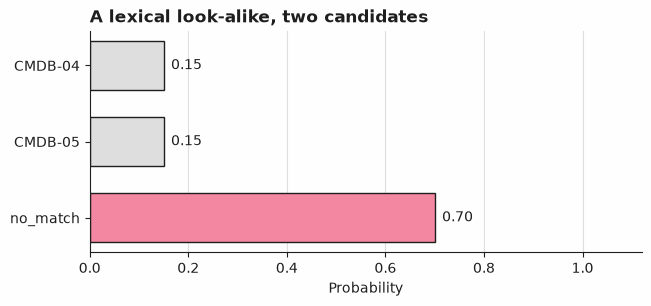

In [5]:
lookalike_candidates, lookalike_answer = decide(example)
print(example.fields["vendor"], "/", example.fields["product"])
show_answer(lookalike_answer)
plot_answer_probabilities(lookalike_answer, title="A lexical look-alike, two candidates")

InkPress Reader is a different, free product from the paid InkPress editor CMDB-04 holds -- but it shares enough wording with it ("Candlewood", "InkPress") to be retrieved as a candidate at a meaningful overlap (0.67, well above the thin single-word overlaps this recipe's decoys use elsewhere). The stored answer correctly puts `no_match` well ahead, at a confidence of 0.55: `(0.70 - 1/3) / (2/3)`, with three options on offer (two candidates plus `no_match`). The next section applies the rule to this answer too, and a `validation` asset further down gets this exact trap wrong.

In [6]:
zero_example = next(e for e in examples if e.id == "d02-zero-candidate")
zero_candidates, zero_answer = decide(zero_example)
print(zero_example.fields["vendor"], "/", zero_example.fields["product"])
print("candidates retrieved:", zero_candidates)
print("answer:", zero_answer)

Panelcraft / Panelcraft Design
candidates retrieved: []
answer: None


Nothing in the sixteen-record pool shares any normalized vendor or product wording with "Panelcraft" / "Panelcraft Design", so `shortlist` returns an empty list and `zero_answer` is `None` -- no request was ever made for this asset. `match_record` is never even called for it; `helpers.no_candidate_resolution`, used in "Python's part" below, resolves it directly to `no_match`, the same forced-answer convention a single-option `Choice` would otherwise need.

In [7]:
many_example = next(e for e in examples if e.id == "d03-decoy-many")
many_candidates, many_answer = decide(many_example)
print(many_example.fields["vendor"], "/", many_example.fields["product"])
print("candidate count:", len(many_candidates), many_candidates)
show_answer(many_answer)

Hedgepath / Hedgepath Enterprise Server
candidate count: 5 ['CMDB-01', 'CMDB-02', 'CMDB-03', 'CMDB-08', 'CMDB-16']
Choice: no_match (confidence 0.47)
  no_match  0.56  ###########
  CMDB-01   0.09  ##
  CMDB-02   0.09  ##
  CMDB-03   0.09  ##
  CMDB-08   0.09  ##
  CMDB-16   0.09  ##
Provenance: synthetic


"Hedgepath Enterprise Server" shares a single generic word each with five unrelated canonical records: "server" with all three Northcastle LedgerStack Server records (CMDB-01/02/03) and "enterprise" with both Redfern Enterprise OS siblings (CMDB-08 and CMDB-16, which differ from each other only by edition) -- enough for all five to be retrieved (`MAX_CANDIDATES`, reached here), none of it evidence that this is actually any of them. `no_match` leads clearly regardless, at a confidence of 0.47 over six options. This asset is kept in `demo`, not `validation` or `test`, precisely so that the sentence above ("`test` is ... not peeked at here") stays true: the longest candidate list in this recipe is shown here, not inside a scored split.

In [8]:
wrong_example = next(e for e in examples if e.id == "v13-lookalike-wrong")
wrong_candidates, wrong_answer = decide(wrong_example)
print(wrong_example.fields["vendor"], "/", wrong_example.fields["product"])
show_answer(wrong_answer)

Candlewood / InkPress Reader IC
Choice: CMDB-04 (confidence 0.10)
  CMDB-04   0.40  ########
  CMDB-05   0.30  ######
  no_match  0.30  ######
Provenance: synthetic


The [**gold label**](../../docs/glossary.md#gold-label) here -- the correct answer written down in `labels.jsonl` before this notebook ever runs, decided from the matching rule above and not from the model -- is `no_match`: this is the same InkPress Reader trap shown above, just worded differently. The stored answer gets it wrong: it names CMDB-04 (the real, paid InkPress) at a confidence of 0.10, not `no_match`. This is the one wrong answer this recipe places in `validation` itself, on purpose: without it, every real-candidate answer in `validation` would be correct, and the confidence gate chosen two sections down would have nothing to cut on.

## Python's part

Jev supplies the judgment; what happens with it is code. `match_record` in `helpers.py` links a confident real candidate to the asset, reports `no_match` as a final, un-gated result whatever its confidence (CONTRIBUTING.md section 4's three-part test -- see "The simulated side effects" below for all three), sends an option outside the retrieved candidates to review as a defensive check (`build_questions` never actually offers such an option, but the rule does not trust that silently), and sends a real candidate below the gate to review instead of linking on a guess. An asset with no candidates at all never reaches `match_record`: `no_candidate_resolution` resolves it directly, the same forced-answer convention that keeps `build_questions` from ever building a single-option `Choice`. `tests/test_helpers.py` checks the rule at the boundary, outside 0 to 1, for a confident and a low-confidence answer of every candidate shape, and for `no_match` at both a high and a low confidence, so a rule that quietly exempted a candidate from the gate, or started gating `no_match` on confidence after all, would fail it.

The [**confidence gate**](../../docs/glossary.md#confidence-gate) itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest gate whose answered subset is perfectly accurate, over the `validation` answers that name a real candidate (the ones that name `no_match`, and the assets with no candidates at all, are excluded from this selection on purpose -- `match_record` never applies the gate to either, so feeding their confidence into the same selection would tune a gate the rule does not have). `v13-lookalike-wrong` above is the one wrong answer in that pool; the frozen gate is the lowest cut that excludes it. Applying that frozen gate to the four answers shown above, plus one clearly confident true match for contrast, shows every outcome the rule can produce -- including, for the first time, an asset sent to `review` -- without yet touching the simulated side effects (those happen for real, over every scored asset, in the Evaluation section below).

In [9]:
val_examples = select_split(examples, "validation")
val_decided = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]

# Only the answers that name a real candidate go into the gate selection: no_match is never
# gated on confidence, and an asset with no candidates was never asked at all, so neither has a
# confidence that belongs in this selection.
real_match = [
    (a.choice == g, a.confidence)
    for (_c, a), g in zip(val_decided, val_gold, strict=True)
    if a is not None and a.choice != helpers.NO_MATCH
]
real_correct = [correct for correct, _ in real_match]
real_confidence = [conf for _, conf in real_match]
n_wrong_in_pool = sum(1 for correct in real_correct if not correct)
gate = select_confidence_threshold(real_correct, real_confidence, target_accuracy=1.0)
print(
    f"chosen confidence gate, frozen from here on: {gate:.4f} "
    f"(over {len(real_match)} real-candidate matches in validation, "
    f"{n_wrong_in_pool} of them wrong){selection}{check}"
)

confident_example = next(e for e in val_examples if e.id == "v01-inkpress")
confident_candidates, confident_answer = decide(confident_example)
for shown_example, (shown_candidates, shown_answer) in (
    (example, (lookalike_candidates, lookalike_answer)),
    (zero_example, (zero_candidates, zero_answer)),
    (wrong_example, (wrong_candidates, wrong_answer)),
    (confident_example, (confident_candidates, confident_answer)),
):
    if shown_answer is None:
        result = helpers.no_candidate_resolution(shown_example.fields["asset_id"])
        print(f"{result.asset_id}: no candidates -> {result.outcome} ({result.reason})")
        continue
    result = helpers.match_record(
        shown_example.fields["asset_id"], shown_candidates, shown_answer, gate
    )
    print(
        f"{result.asset_id}: {shown_answer.choice} at confidence "
        f"{shown_answer.confidence:.2f} -> {result.outcome} ({result.reason})"
    )

chosen confidence gate, frozen from here on: 0.7450 (over 16 real-candidate matches in validation, 1 of them wrong) (a selection step, not a reported result) (a pipeline check, not a Jev result)
AST-3001: no_match at confidence 0.55 -> no_match (no canonical record matches)
AST-3002: no candidates -> no_match (no candidate record shares any vendor or product wording with this asset)
AST-1013: CMDB-04 at confidence 0.10 -> review (confidence below the threshold)
AST-1001: CMDB-04 at confidence 0.79 -> linked (confident match)


Why that particular cut and not some other number nearby? `selective_curve` sweeps every distinct confidence value this pool actually has and reports the coverage, accuracy and risk of cutting there, so the choice above can be checked rather than taken on faith. [**Coverage**](../../docs/glossary.md#coverage) is the fraction of this pool a cut answers (confidence at or above it) instead of sending to [review](../../docs/glossary.md#review); [**risk**](../../docs/glossary.md#risk) is `1 - accuracy` among those answered. This recipe's `validation` real-candidate confidences fall into two bands, well apart: a low band (the wrong look-alike and one correct-but-cautious answer, both under 0.11) and a confident band (everything else, 0.745 and above). Cutting anywhere in the confident band answers exactly that band and excludes the whole low band, giving the same accuracy and the same risk no matter where in that band the cut sits -- only coverage changes within it -- which is why `select_confidence_threshold` returns 0.745, the *lowest* value in that band (more coverage, same accuracy), not because 0.745 is special in any other way. Cutting anywhere in the low band lets the wrong look-alike through.

cut-off 0.8267: coverage 0.0625, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
cut-off 0.8133: coverage 0.1250, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
cut-off 0.8000: coverage 0.1875, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
cut-off 0.7900: coverage 0.3125, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
cut-off 0.7867: coverage 0.4375, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
cut-off 0.7750: coverage 0.5625, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
cut-off 0.7600: coverage 0.7500, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
cut-off 0.745

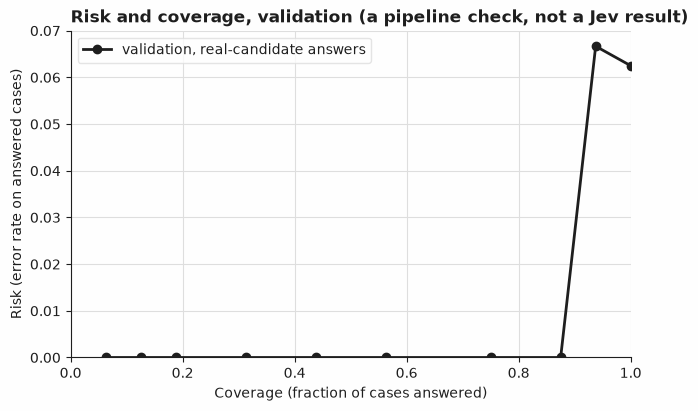

In [10]:
curve = selective_curve(real_correct, real_confidence)
zipped = zip(curve.thresholds, curve.coverage, curve.accuracy, curve.risk, strict=True)
for t, cov, acc, risk in zipped:
    chosen = " <- chosen" if t == gate else ""
    print(
        f"cut-off {t:.4f}: coverage {cov:.4f}, accuracy {acc:.4f}, risk {risk:.4f}{selection}{check}{chosen}"
    )
plot_risk_coverage(
    curve,
    label="validation, real-candidate answers",
    title=f"Risk and coverage, validation{check}",
)

### Where the gold match sits in its own shortlist

Because retrieval ranks candidates and the question lists them in that order, a rule that simply always picked the shortlist's first entry would score well if the true match is always first -- an option-order confound. The table below counts, for every scored asset whose gold label names a real canonical record, which position in that asset's own shortlist the gold record actually occupies (`no_match` covers every asset whose gold label is `no_match`, including the four with no candidates at all). Every real gold record is, by construction, always somewhere in its own shortlist (a record's self-overlap is always the maximum possible, 1.0, so it is never excluded by the floor retrieval applies); the cell asserts this rather than leaving a silently unreachable case in the count.

In [11]:
rank_counts = Counter()
for e in scored:
    gold = labels[e.id]
    if gold == helpers.NO_MATCH:
        rank_counts["no_match"] += 1
        continue
    candidates, _answer = decide(e)
    if gold not in candidates:
        raise AssertionError(f"{e.id}: gold {gold} was not retrieved, which should be impossible")
    rank_counts[f"position {candidates.index(gold) + 1}"] += 1

print(f"gold-match position across {len(scored)} scored assets{check}:")
for position, count in sorted(rank_counts.items()):
    print(f"  {position}: {count}")

gold-match position across 40 scored assets (a pipeline check, not a Jev result):
  no_match: 10
  position 1: 24
  position 2: 4
  position 3: 2


The gold match sits first in most real-match assets, simply because nothing else in this catalog shares an asset's vendor and product as closely as its own record does -- there is no option-order confound to correct for *there*. It sits second or third for two families that always tie in retrieval: CMDB-01/02/03 (version plays no part in retrieval, so all three list in id order whichever one is right) and CMDB-08/CMDB-16 (edition plays no part either). Those are exactly the cases "always answer option 1" gets wrong, and exactly the cases the baselines below are measured against.

## Evaluation

The confidence gate was chosen and frozen above, on `validation`. This section first checks the rule's raw judgment -- **link accuracy**, the fraction of assets where the stored answer's single most probable option (or, for a zero-candidate asset, the forced `no_match`) equals the gold label, before any confidence gate is applied at all -- against two trivial, Jev-free baselines, then reports what the frozen rule actually does: `helpers.match_record` (or `no_candidate_resolution`) is applied to every example in `validation` and in `test`, this time with `helpers.record_resolution` actually carrying out the simulated side effects (a link recorded in `actions`, an asset queued in `backlog`, or an asset held in `queue`) for real, over every scored asset, and the outcome counts below come from what the rule actually returned, not from a separate reimplementation of the same condition. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

### Two baselines the rule must beat

`helpers.baseline_always_top` always links to the shortlist's first (highest-overlap) candidate, or `no_match` only when retrieval found none -- it never chooses `no_match` while any candidate exists. `helpers.baseline_overlap_cutoff` instead picks the single best-overlap record across the whole catalog (the same tie-break as retrieval) and reports it only when its overlap clears a fixed cut-off (0.6), else `no_match`. Neither baseline calls Jev, and neither reads version or edition at all -- so both are exactly as unable to tell CMDB-01/02/03 or CMDB-08/CMDB-16 apart as plain word overlap is. If the stored answers' link accuracy does not clearly beat both, there is no evidence in this notebook that reading the version and edition text added anything over the retrieval step alone.

In [12]:
def link_accuracy(exs):
    results = []
    for e in exs:
        candidates, answer = decide(e)
        label = helpers.NO_MATCH if answer is None else answer.choice
        results.append(label)
    return accuracy([labels[e.id] for e in exs], results)


def baseline_accuracy(exs, predict):
    correct = sum(1 for e in exs if predict(e) == labels[e.id])
    return correct / len(exs)


def always_top(e):
    return helpers.baseline_always_top(helpers.shortlist(e.fields["vendor"], e.fields["product"]))


def overlap_cutoff(e):
    return helpers.baseline_overlap_cutoff(e.fields["vendor"], e.fields["product"])


def rule_predicted(e):
    _c, a = decide(e)
    return helpers.NO_MATCH if a is None else a.choice


test_examples_preview = select_split(examples, "test")
for split_name, exs, split_label in (
    ("validation", val_examples, selection + check),
    ("test", test_examples_preview, check),
):
    wrong_top = [e.id for e in exs if always_top(e) != labels[e.id]]
    wrong_overlap = [e.id for e in exs if overlap_cutoff(e) != labels[e.id]]
    wrong_rule = [e.id for e in exs if rule_predicted(e) != labels[e.id]]
    print(f"{split_name}, {len(exs)} examples{split_label}:")
    print(
        f"  baseline (always link to the top candidate): {baseline_accuracy(exs, always_top):.4f}{split_label}"
    )
    print(f"    wrong on: {wrong_top}")
    print(
        f"  baseline (best overlap, cut-off 0.6): {baseline_accuracy(exs, overlap_cutoff):.4f}{split_label}"
    )
    print(f"    wrong on: {wrong_overlap}")
    print(
        f"  rule's own link accuracy (raw choice vs. gold): {link_accuracy(exs):.4f}{split_label}"
    )
    print(f"    wrong on: {wrong_rule}")
    right_top_wrong_rule = sorted(set(wrong_rule) - set(wrong_top))
    right_overlap_wrong_rule = sorted(set(wrong_rule) - set(wrong_overlap))
    print(f"  rule wrong where always-top baseline is right: {right_top_wrong_rule}")
    print(f"  rule wrong where overlap-cutoff baseline is right: {right_overlap_wrong_rule}")
    # How much of each baseline's error is a no_match gold it can never (always_top) or only
    # sometimes (overlap_cutoff) answer, versus a same-vendor-and-product family tie it can
    # never resolve either way -- derived here rather than summarized loosely in prose.
    nomatch_top = [eid for eid in wrong_top if labels[eid] == helpers.NO_MATCH]
    nomatch_overlap = [eid for eid in wrong_overlap if labels[eid] == helpers.NO_MATCH]
    recovered = [eid for eid in nomatch_top if eid not in wrong_overlap]
    print(
        f"  of always-top's {len(wrong_top)} wrong, {len(nomatch_top)} are no_match golds "
        f"({len(nomatch_top)}/{len(wrong_top)})"
    )
    print(
        f"  of overlap-cutoff's {len(wrong_overlap)} wrong, {len(nomatch_overlap)} are no_match golds "
        f"({len(nomatch_overlap)}/{len(wrong_overlap)})"
    )
    print(
        f"  overlap-cutoff recovers {len(recovered)} of always-top's {len(nomatch_top)} "
        f"no_match misses: {recovered}"
    )
    print()

validation, 20 examples (a selection step, not a reported result) (a pipeline check, not a Jev result):
  baseline (always link to the top candidate): 0.7000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
    wrong on: ['v10-ledger-2020', 'v11-ledger-2023-lowconf', 'v12-ledger-missing-version', 'v13-lookalike-wrong', 'v16-huddle-decoy', 'v20-entos-workstation']
  baseline (best overlap, cut-off 0.6): 0.8000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
    wrong on: ['v10-ledger-2020', 'v11-ledger-2023-lowconf', 'v12-ledger-missing-version', 'v20-entos-workstation']
  rule's own link accuracy (raw choice vs. gold): 0.9500 (a selection step, not a reported result) (a pipeline check, not a Jev result)
    wrong on: ['v13-lookalike-wrong']
  rule wrong where always-top baseline is right: []
  rule wrong where overlap-cutoff baseline is right: ['v13-lookalike-wrong']
  of always-top's 6 wrong, 3 are no_match golds (3/6)
  of 

On both splits the rule's own link accuracy is clearly above either baseline, but the gap is not one single thing, and "most"/"recovers most" overstates it on at least one split, so the cell above derives and prints the actual shares instead. Half of `baseline_always_top`'s wrong answers on each split are assets whose gold is `no_match` (3 of 6 on both `validation` and `test`), which it can never answer at all while any candidate exists (`v12`, `v13`, `v16`; `t10`, `t11`, `t13`); the rest are same-vendor-and-product family ties (`v10`, `v11`, `v20`; `t08`, `t09`, `t20`), which no amount of word overlap can resolve either way. `baseline_overlap_cutoff` recovers 2 of those 3 `no_match` misses on `validation` (1 of 4 of its own wrong answers is a `no_match` gold) but only 1 of 3 on `test` (2 of 5) -- not "most" on both splits, just on one of them. Neither baseline resolves a single family tie, which is why both still fail on every one of `v10`/`v11`/`v20`/`t08`/`t09`/`t20`: that part of the gap, and only that part, is what reading version and edition text buys that word overlap provably cannot. The comparison is not one-directional, either: `baseline_overlap_cutoff` is *right* where the rule itself is wrong on `v13` in `validation` (that look-alike's overlap, 0.5, happens to sit below the 0.6 cut-off, so the baseline rejects it correctly while the stored answer does not), and on `test` both baselines are right where the rule is wrong, on `t14` and `t15` (printed above as "rule wrong where ... baseline is right").

In [13]:
def report(chosen, decided_pairs, gate):
    """Apply match_record (or no_candidate_resolution) to every answer and tally what it
    actually did, recording the simulated side effect for each one along the way."""
    results = []
    for e, (c, a) in zip(chosen, decided_pairs, strict=True):
        if a is None:
            result = helpers.no_candidate_resolution(e.fields["asset_id"])
        else:
            result = helpers.match_record(e.fields["asset_id"], c, a, gate)
        helpers.record_resolution(result, a, actions, backlog, queue)
        results.append(result)
    counts = {helpers.LINKED: 0, helpers.REVIEW: 0, helpers.NO_MATCH_OUTCOME: 0}
    for r in results:
        counts[r.outcome] += 1
    return results, counts


val_results, val_counts = report(val_examples, val_decided, gate)
val_answers_label = [r.label for r in val_results]
# Snapshot the side-effect tallies right after this split, so each split's own contribution can
# be reported under its own label (a validation number never carries the `check` label alone).
actions_after_validation = len(actions)
backlog_after_validation = len(backlog)
queue_after_validation = len(queue)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(
    f"link accuracy (raw choice vs. gold label): {accuracy(val_gold, val_answers_label):.4f}{selection}{check}"
)
print(
    f"linked: {val_counts[helpers.LINKED]}, review: {val_counts[helpers.REVIEW]}, "
    f"no_match: {val_counts[helpers.NO_MATCH_OUTCOME]} (of {len(val_examples)}){selection}{check}"
)
val_reviewed = [r for r in val_results if r.outcome == helpers.REVIEW]
print(f"reviewed in validation, listed individually{selection}{check}:")
for r in val_reviewed:
    print(f"  {r.asset_id}: {r.label} at the gate, sent to review ({r.reason})")

validation, 20 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
link accuracy (raw choice vs. gold label): 0.9500 (a selection step, not a reported result) (a pipeline check, not a Jev result)
linked: 14, review: 2, no_match: 4 (of 20) (a selection step, not a reported result) (a pipeline check, not a Jev result)
reviewed in validation, listed individually (a selection step, not a reported result) (a pipeline check, not a Jev result):
  AST-1011: CMDB-03 at the gate, sent to review (confidence below the threshold)
  AST-1013: CMDB-04 at the gate, sent to review (confidence below the threshold)


Two `validation` assets are reviewed: `AST-1013` (`v13-lookalike-wrong` above -- wrong, and this is exactly the error the confidence gate was chosen to exclude) and one correct-but-cautious asset naming the right record at a confidence below the frozen gate. That is the **coverage** cost of excluding `AST-1013`: both sit in the same low confidence band, well apart from every confident answer, so the gate cannot single `AST-1013` out without also catching the cautious one -- the sweep above shows there is no cut that keeps it while still excluding `AST-1013`.

In [14]:
test_examples = select_split(examples, "test")
test_decided = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]
test_answers_label = [(helpers.NO_MATCH if a is None else a.choice) for _c, a in test_decided]

test_results, test_counts = report(test_examples, test_decided, gate)
print(f"test, {len(test_examples)} examples, confidence gate {gate:.4f} frozen{check}")
print(
    f"link accuracy (raw choice vs. gold label): {accuracy(test_gold, test_answers_label):.4f}{check}"
)
print(
    f"linked: {test_counts[helpers.LINKED]}, review: {test_counts[helpers.REVIEW]}, "
    f"no_match: {test_counts[helpers.NO_MATCH_OUTCOME]} (of {len(test_examples)}){check}"
)
wrong_test = [
    (r.asset_id, r.outcome, r.label, test_gold[i])
    for i, r in enumerate(test_results)
    if r.label != test_gold[i]
]
print(f"wrong in test, listed individually{check}:")
for asset_id, outcome, label, gold in wrong_test:
    print(f"  {asset_id}: outcome {outcome}, named {label}, gold {gold}")

test, 20 examples, confidence gate 0.7450 frozen (a pipeline check, not a Jev result)
link accuracy (raw choice vs. gold label): 0.8500 (a pipeline check, not a Jev result)
linked: 12, review: 3, no_match: 5 (of 20) (a pipeline check, not a Jev result)
wrong in test, listed individually (a pipeline check, not a Jev result):
  AST-2010: outcome linked, named CMDB-03, gold no_match
  AST-2014: outcome no_match, named no_match, gold CMDB-09
  AST-2015: outcome review, named CMDB-02, gold CMDB-01


Three of `test`'s twenty assets are wrong, in three different ways (printed above, derived from the rule's own results rather than typed). `AST-2010` (`t10-ledger-missing-version-wrong`) has no observed version at all -- this recipe's policy is that Python never asks Jev to guess a major version it cannot see, so the gold label is `no_match` -- but the stored answer confidently names CMDB-03 anyway, at a confidence that clears the frozen gate: a real, wrong link the confidence gate lets straight through, because the gate only protects against *low* confidence, not against being confidently wrong. `AST-2014` (`t14-ticketforge-missed`) is a real match (CMDB-09), but the stored answer names `no_match` instead, at a confidence (0.58) *below* the frozen gate -- wrong, and accepted anyway, because `match_record` never runs `no_match` past the confidence gate at all, however low its own confidence is. `AST-2015` (`t15-ledger-2017-lowconf`) is a real match (CMDB-01), but the stored answer names the wrong sibling in the same version family (CMDB-02) at a low confidence: wrong, and caught (sent to `review`). Two further assets are correct but held back by the same low-confidence pattern as `validation`'s cautious answer above -- the coverage cost repeats in `test`. That spread -- one wrong link the gate lets through, one wrong `no_match` the gate was never asked about, one wrong answer it does catch -- is the point of the side-effect summary two cells down.

`no_match`'s own precision and recall, reported separately, as the use case asks: **precision** is the share of assets the rule called `no_match` that truly had no matching record; **recall** is the share of assets truly addressed by no canonical record that the rule actually called `no_match`; **support** is how many `test` assets actually carry the `no_match` gold label, so a recall figure is only as meaningful as its support is large.

In [15]:
all_labels = sorted(helpers.CMDB_RECORDS) + [helpers.NO_MATCH]
per_class = per_class_metrics(test_gold, test_answers_label, labels=all_labels)
no_match_metrics = per_class[helpers.NO_MATCH]
print(
    f"no_match precision {no_match_metrics.precision:.4f}, recall {no_match_metrics.recall:.4f}, "
    f"support {no_match_metrics.support}{check}"
)

no_match precision 0.8000, recall 0.8000, support 5 (a pipeline check, not a Jev result)


`no_match`'s precision (0.8000) is 4 of the 5 assets the rule called `no_match` that truly had no matching record: the fifth is `AST-2014`, a real CMDB-09 match the rule misreads as having no match at all. Its recall (0.8000) is 4 of the 5 `test` assets truly addressed by no canonical record: the fifth, `AST-2010`, has no version reported and is wrongly linked to CMDB-03 instead of being called `no_match`. Precision and recall land on the same fraction here only because this fixture set happens to have exactly one error on each side (one false `no_match`, one missed `no_match`); nothing ties the two together in general.

### The simulated side effects

`match_record`'s outcomes are not reapplied through a generic selective-prediction helper here: `no_match` is never gated on confidence at all, and an asset with no candidates is never gated either (it never reaches `match_record`), so a helper that gates every example on one confidence cut would score a gate this rule does not have. `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)` is the shared helper for exactly this shape of rule: `accepted[i]` is whether the asset was answered (`linked` or `no_match`) rather than sent to `review`, as the rule itself decided, and it reports **coverage** (the fraction of assets answered), **accuracy** (the fraction of those right) and **risk** (`1 - accuracy`). `helpers.accepted_and_correct` builds its two arguments from a list of `Resolution`s. `evaluate_outcomes` has no notion of a second, narrower outcome inside "answered" -- `linked` versus `no_match` -- so `helpers.false_link_rate` computes that part directly: the share of `linked` assets alone whose record is wrong, the **false-link rate** this use case names, and the only way the one outcome with a side effect, writing a link from an asset to a canonical record, can actually be wrong. `actions`, `backlog` and `queue` below are three `jev_cookbook.simulation` containers: nothing here sends, moves or writes anything real (CONTRIBUTING.md, section 4), and every entry says so.

CONTRIBUTING.md section 4 lets a complete-answer fallback stand as a final result at any confidence, with no further gate, only when it passes a three-part test: (a) it is a complete answer, not a deferral; (b) choosing it records no action in the `ActionLog`; (c) being wrong leaves nothing standing beyond the missed item itself, measured against sending it to review instead. `no_match` passes all three here: (a) it is a real judgment ("no canonical record fits"), not a request for someone else to decide; (b) choosing it writes nothing to the CMDB -- an unmatched asset is only ever noted in `backlog`, printed below labelled **noted, no action** so a reader can see the entry records nothing taken, only something for a person to look at later, whether a new canonical record is needed or the asset is a known one that simply needs a version re-scan; and (c) a wrong `no_match` leaves only the missed match itself sitting in that backlog, exactly what sending it to review would also have left pending. That exemption is not a corner case in this fixture set: every stored `no_match` answer's own confidence is below the frozen gate (printed below), so without the exemption none of them would be accepted at all. The cell below also computes what applying the gate to `no_match` as well would have done on `test`, so the exemption's cost and benefit are both visible rather than argued in prose.

In [16]:
import dataclasses

val_gold_by_asset = {e.fields["asset_id"]: g for e, g in zip(val_examples, val_gold, strict=True)}
val_accepted, val_correct = helpers.accepted_and_correct(val_results, val_gold_by_asset)
val_outcomes = evaluate_outcomes(val_accepted, val_correct)
val_flr = helpers.false_link_rate(val_results, val_gold_by_asset)
print(
    f"validation: linked {val_counts[helpers.LINKED]}, reviewed {val_counts[helpers.REVIEW]}, "
    f"no_match {val_counts[helpers.NO_MATCH_OUTCOME]} (coverage {val_outcomes.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_outcomes.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_outcomes.risk:.4f}{selection}{check}")
print(f"false-link rate (wrong among linked): {val_flr:.4f}{selection}{check}")
print(
    f"links recorded in validation: {actions_after_validation}, assets backlogged: "
    f"{backlog_after_validation}, assets queued for review: {queue_after_validation}{selection}{check}"
)

test_gold_by_asset = {
    e.fields["asset_id"]: g for e, g in zip(test_examples, test_gold, strict=True)
}
test_accepted, test_correct = helpers.accepted_and_correct(test_results, test_gold_by_asset)
test_outcomes = evaluate_outcomes(test_accepted, test_correct)
test_flr = helpers.false_link_rate(test_results, test_gold_by_asset)
print()
print(
    f"test: linked {test_counts[helpers.LINKED]}, reviewed {test_counts[helpers.REVIEW]}, "
    f"no_match {test_counts[helpers.NO_MATCH_OUTCOME]} (coverage {test_outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_outcomes.accuracy:.4f}{check}")
print(f"risk among those answered: {test_outcomes.risk:.4f}{check}")
print(f"false-link rate (wrong among linked): {test_flr:.4f}{check}")
print(
    f"links recorded in test: {len(actions) - actions_after_validation}, assets backlogged: "
    f"{len(backlog) - backlog_after_validation}, assets queued for review: "
    f"{len(queue) - queue_after_validation}{check}"
)

print()
test_false_links = [
    r
    for r in test_results
    if r.outcome == helpers.LINKED and r.label != test_gold_by_asset[r.asset_id]
]
if test_false_links:
    linked_asset = test_false_links[0].asset_id
    entry = next(e for e in actions.by_kind("link_asset") if e["payload"]["asset"] == linked_asset)
    print(f"the one false link in test, recorded but never executed{check}:")
    print(json.dumps(entry, indent=2))
else:
    print(f"no false link occurred in this run{check}")

print()
print(f"confidence of every stored no_match answer, against the frozen gate ({gate:.4f}){check}:")
for e in examples:
    c, a = decide(e)
    if a is not None and a.choice == helpers.NO_MATCH:
        print(f"  {e.id}: {a.confidence:.4f} (>= gate? {a.confidence >= gate})")

print()


def strict_resolve(exs):
    """The counterfactual: the same gate, applied to no_match too (a zero-candidate asset
    still has nothing to gate, since it never had a confidence in the first place)."""
    results = []
    for e, (c, a) in zip(exs, (decide(e) for e in exs), strict=True):
        if a is None:
            results.append(helpers.no_candidate_resolution(e.fields["asset_id"]))
            continue
        r = helpers.match_record(e.fields["asset_id"], c, a, gate)
        if r.outcome == helpers.NO_MATCH_OUTCOME and a.confidence < gate:
            r = dataclasses.replace(
                r, outcome=helpers.REVIEW, reason="confidence below the threshold"
            )
        results.append(r)
    return results


test_strict = strict_resolve(test_examples)
strict_accepted, strict_correct = helpers.accepted_and_correct(test_strict, test_gold_by_asset)
strict_outcomes = evaluate_outcomes(strict_accepted, strict_correct)
print(f"counterfactual on test, no_match gated too (not what this notebook ships){check}:")
print(
    f"  as shipped:        coverage {test_outcomes.coverage:.4f}, accuracy {test_outcomes.accuracy:.4f}, risk {test_outcomes.risk:.4f}{check}"
)
print(
    f"  no_match gated too: coverage {strict_outcomes.coverage:.4f}, accuracy {strict_outcomes.accuracy:.4f}, risk {strict_outcomes.risk:.4f}{check}"
)

print()
print(
    f"one backlog entry (noted, no action), with the candidates it was offered (if any){selection}{check}:"
)
print(json.dumps(backlog.to_dicts()[0], indent=2))
print()
print(f"one review item, with the candidates it was offered{selection}{check}:")
print(json.dumps(queue.to_dicts()[0], indent=2))

validation: linked 14, reviewed 2, no_match 4 (coverage 0.9000) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
false-link rate (wrong among linked): 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
links recorded in validation: 14, assets backlogged: 4, assets queued for review: 2 (a selection step, not a reported result) (a pipeline check, not a Jev result)

test: linked 12, reviewed 3, no_match 5 (coverage 0.8500) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8824 (a pipeline check, not a Jev result)
risk among those answered: 0.1176 (a pipeline check, not a Jev result)
false-link rate (wrong among linked): 0.0833 (a pipeline check, not a Jev result)
links recorded i

`validation`'s risk is 0.0000 and its false-link rate is 0.0000: the only wrong answer in `validation`, `AST-1013`, is reviewed rather than answered, so nothing wrong is ever linked or reported there -- that is what choosing the confidence gate on `validation` is supposed to buy, and it does, on this split. `test`'s risk and false-link rate are both well above zero: risk counts both `AST-2010` (the wrong link) and `AST-2014` (the wrong `no_match`) against the assets answered, while the false-link rate counts only `AST-2010` against the assets actually linked, since `AST-2014` never linked anything.

The counterfactual printed above is the real price of exempting `no_match` from the gate: with it ungated (as shipped), `test` answers more (higher coverage) but one of those extra answers is `AST-2014`, the wrong `no_match`, which also lowers accuracy and raises risk relative to gating it too. §4 permits the exemption specifically because choosing `no_match` writes nothing -- `AST-2014` costs a missed match sitting in the backlog, not a wrong write to the CMDB -- and that is the trade this fixture set actually shows: lower coverage and higher accuracy if `no_match` were gated as well, in exchange for catching `AST-2014` and sending it to a person instead. The link recorded above for `AST-2010` is a different trade entirely: it is this run's one false link, and nothing about running this notebook ever turns that record into a real write to a real CMDB.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the retrieval, the rule and the evaluation behave as designed on 40 scored assets (plus 3 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, three of them wrong in `test` and one in `validation`, each wrong in a different way, so every number above describes this fixture set and not a model.

In [17]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard asset to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `match_record` (or `no_candidate_resolution`) sends it.
- Change the confidence gate's target in the evaluation cell (`target_accuracy=1.0` to `0.9`) and rerun from "Python's part": the gate drops to 0.0667 -- `v11-ledger-2023-lowconf`'s own confidence, not `v13-lookalike-wrong`'s -- which links the look-alike itself, because a target of 0.9 admits one real-candidate mistake into the answered pool, and the lowest cut that does so without admitting a second one happens to be set by the lowest *correct* confidence, not the wrong answer's own. (Checked by actually running it, not just read off the sweep.)
- Add a seventeenth canonical record sharing a vendor with CMDB-01/02/03 or with CMDB-08/CMDB-16 and rerun `build_fixtures.py`: both families already retrieve every sibling they have, so a new one joining either family is the easiest way to see whether `MAX_CANDIDATES` (5, already reached by `t13-forge-decoy` and `d03-decoy-many`) ever starts truncating a shortlist that would otherwise be longer.
- Neighbouring recipes: [`18-duplicate-incident-matching`](../18-duplicate-incident-matching/), which retrieves a fixed-size shortlist from a smaller pool for the same "candidates plus no_match" shape over incident tickets instead of software assets; [`08-faq-selection`](../08-faq-selection/), whose candidate list never varies at all; and [`21-quiz-answer-adjudication`](../21-quiz-answer-adjudication/), which settles what it can in Python before ever building a candidate set of its own: its own `review` outcome is the structural match for this recipe's `review`, reached only by a deferral and never a confident final answer, while this recipe's `no_match` -- a complete answer, exempted from the gate under CONTRIBUTING.md section 4 -- has no counterpart there (21's own `no_match` means something else entirely: the response is wrong).